## Basic overview of dataset "domy"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load the data
df = pd.read_csv("../data/raw/domy.csv")

print(f"Data loaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

Data loaded successfully!
Shape: 1460 rows × 81 columns


In [3]:
df.info()
df.describe(include='all').T

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Id             1460 non-null   int64
 1   MSSubClass     1460 non-null   int64
 2   MSZoning       1460 non-null   str  
 3   LotFrontage    1460 non-null   str  
 4   LotArea        1460 non-null   int64
 5   Street         1460 non-null   str  
 6   Alley          1460 non-null   str  
 7   LotShape       1460 non-null   str  
 8   LandContour    1460 non-null   str  
 9   Utilities      1460 non-null   str  
 10  LotConfig      1460 non-null   str  
 11  LandSlope      1460 non-null   str  
 12  Neighborhood   1460 non-null   str  
 13  Condition1     1460 non-null   str  
 14  Condition2     1460 non-null   str  
 15  BldgType       1460 non-null   str  
 16  HouseStyle     1460 non-null   str  
 17  OverallQual    1460 non-null   int64
 18  OverallCond    1460 non-null   int64
 19  YearBuilt      14

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,1460.0,NaN,NaN,NaN,730.5,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,NaN,NaN,NaN,56.89726,42.300571,20.0,20.0,50.0,70.0,190.0
MSZoning,1460,5,RL,1151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LotFrontage,1460,111,?,259,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LotArea,1460.0,NaN,NaN,NaN,10516.828082,9981.264932,1300.0,7553.5,9478.5,11601.5,215245.0
...,...,...,...,...,...,...,...,...,...,...,...
MoSold,1460.0,NaN,NaN,NaN,6.321918,2.703626,1.0,5.0,6.0,8.0,12.0
YrSold,1460.0,NaN,NaN,NaN,2007.815753,1.328095,2006.0,2007.0,2008.0,2009.0,2010.0
SaleType,1460,9,WD,1267,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SaleCondition,1460,6,Normal,1198,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
data_dict = pd.DataFrame({
    'Column': df.columns,
    'Type': df.dtypes.values,
    #'Non-Null': df.count().values,
    #'Null_%': (df.isnull().sum() / len(df) * 100).values,
    'Unique': [df[col].nunique() for col in df.columns]
})
with pd.option_context('display.max_rows', None):
    display(data_dict)

,Column,Type,Unique
0,Id,int64,1460
1,MSSubClass,int64,15
2,MSZoning,str,5
3,LotFrontage,str,111
4,LotArea,int64,1073
5,Street,str,2
6,Alley,str,3
7,LotShape,str,4
8,LandContour,str,4
9,Utilities,str,2


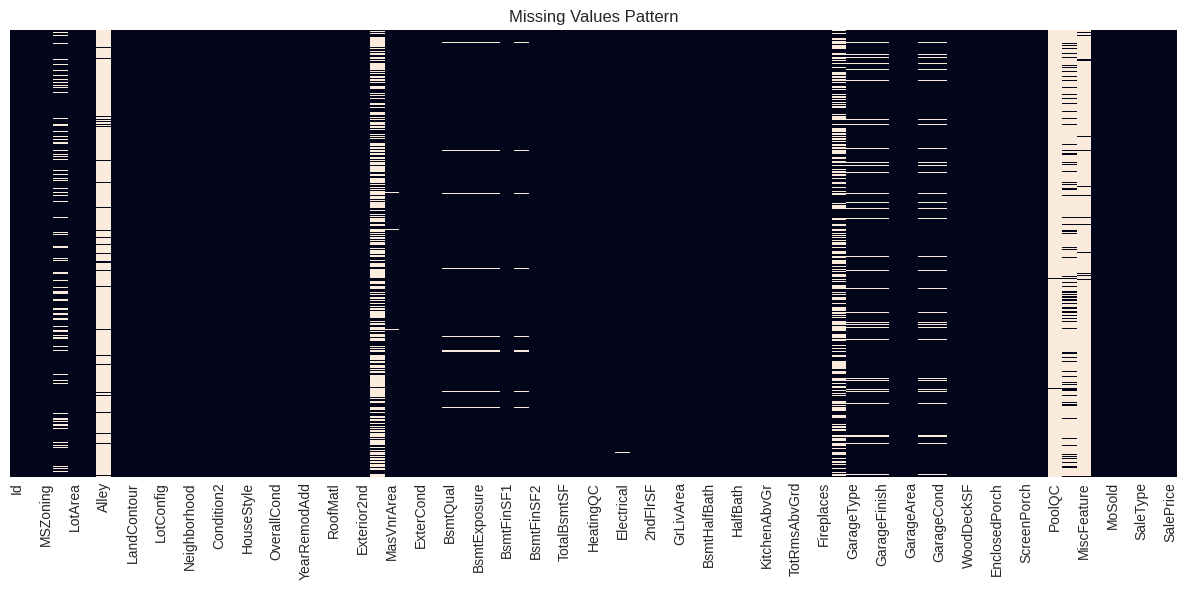

In [6]:
plt.figure(figsize=(12, 6))
for junk in ['?', 'None']:
    df = df.replace(junk, np.nan, inplace=True)
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title('Missing Values Pattern')
plt.tight_layout()
plt.savefig('../docs/figures/01_missing_values.png', dpi=100, bbox_inches='tight')
plt.show()

### Outliers
Cytat z `domy.txt`:
> There are 5 observations that an instructor may wish to remove from the data set before giving it to students (a plot of SALE PRICE versus GR LIV AREA will indicate them quickly). Three of them are true outliers (Partial Sales that likely don't represent actual market values) and two of them are simply unusual sales (very large houses priced relatively appropriately). I would recommend removing any houses with more than 4000 square feet from the data set (which eliminates these 5 unusual observations) before assigning it to students.

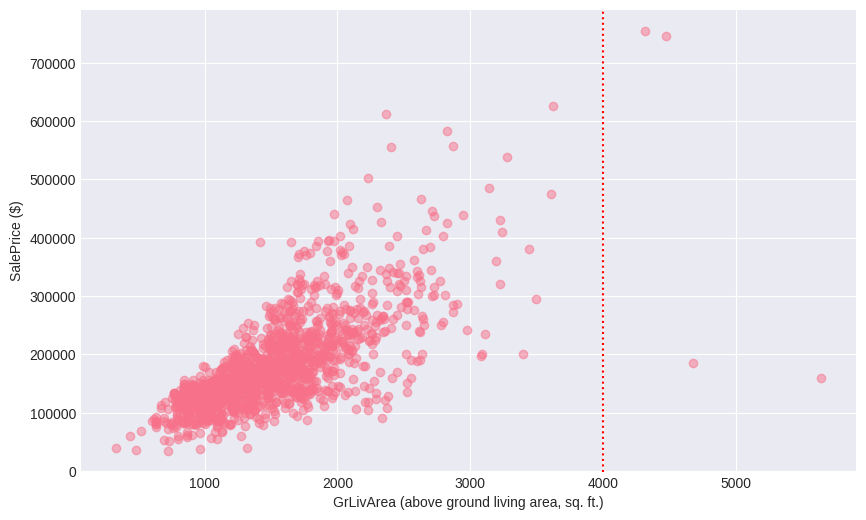

In [7]:
x_feat = 'GrLivArea'
x_feat_desc = 'GrLivArea (above ground living area, sq. ft.)'
x_line = 4000

y_feat = 'SalePrice'
y_feat_desc = 'SalePrice ($)'

plt.figure(figsize=(10, 6))
plt.scatter(df[x_feat], df[y_feat], alpha=0.5)
plt.axvline(x=x_line, color='red', linestyle=':')
plt.xlabel(x_feat_desc)
plt.ylabel(y_feat_desc)
plt.show()

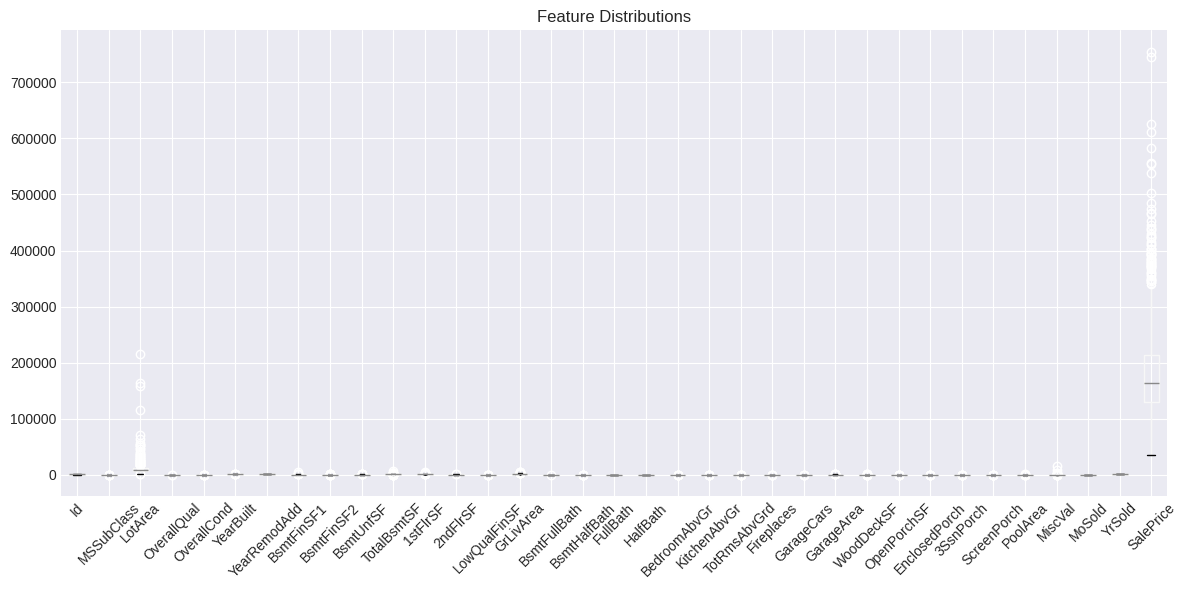

In [10]:
path_input  = '../data/raw/domy.csv'

df = pd.read_csv(path_input)

numeric_cols = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(12, 6))
df[numeric_cols].boxplot(rot=45)  # rot=45 rotates labels
plt.title('Feature Distributions')
plt.tight_layout()
plt.show()

### Summary
1. Dataset shape: 1460 rows × 81 columns
2. 35 ints, 46 strings in the dataset